In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 18: Train a Binary Classifier for Oracle-Good vs Oracle-Bad Candidates

**Objective:** Replace distance regression with a binary classification model that predicts whether a candidate is GT-near (`oracle_good`) or not.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- label consolidated candidates as oracle-good vs oracle-bad
- train a binary classifier on handcrafted candidate features
- rank held-out candidates by predicted probability of being oracle-good
- evaluate top-k performance using classification scores instead of regression scores
- compare classifier ranking against the regression-based ranker from Chapters 16–17

# 🧠 Background Theory

In Chapters 16 and 17, I used a regression model to predict a continuous score based on distance to the nearest GT centroid.

That approach failed because GT-near candidates were ranked too low in the held-out frames. The ranker was not “almost correct”; it was severely misordering the candidate pool.

This chapter changes the learning target.

Instead of predicting a continuous distance-based score, I will train a classifier to answer a simpler question:

> Is this candidate within the GT match radius or not?

That target aligns better with the actual detector decision:
- keep candidates likely to be true cells
- suppress candidates likely to be distractors

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 94.5 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import blob_log
from sklearn.ensemble import RandomForestClassifier

In [4]:
print("Imports successful.")

Imports successful.


# Step 1 — Load the Sample and Ground Truth

I will continue using sample `44b6_12dfb391` so that the classification results can be compared directly to Chapters 13–17.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

volume = zarr.open(zarr_path, mode="r")
image = volume["0"]

geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
nodes_df.head()

Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


# Step 2 — Define Detection, NMS, Feature, and Evaluation Helpers

This notebook reuses the same LoG + NMS + handcrafted feature pipeline from Chapters 16 and 17.

In [6]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)

In [7]:
def add_center_intensity(frame_3d, pred_df):
    pred_df = pred_df.copy()
    intensities = []

    Z, Y, X = frame_3d.shape

    for _, row in pred_df.iterrows():
        z, y, x = int(row["z"]), int(row["y"]), int(row["x"])
        z = np.clip(z, 0, Z - 1)
        y = np.clip(y, 0, Y - 1)
        x = np.clip(x, 0, X - 1)

        intensities.append(float(frame_3d[z, y, x]))

    pred_df["center_intensity"] = intensities
    return pred_df

In [8]:
def consolidate_candidates_3d(pred_df, radius=3.0, score_col="center_intensity"):
    if len(pred_df) == 0:
        return pred_df.copy()

    work_df = pred_df.copy().sort_values(score_col, ascending=False).reset_index(drop=True)
    kept_rows = []

    while len(work_df) > 0:
        keep = work_df.iloc[0]
        kept_rows.append(keep)

        keep_point = np.array([keep["z"], keep["y"], keep["x"]], dtype=float)
        other_points = work_df[["z", "y", "x"]].to_numpy(dtype=float)

        dists = np.sqrt(((other_points - keep_point) ** 2).sum(axis=1))
        work_df = work_df[dists > radius].reset_index(drop=True)

    return pd.DataFrame(kept_rows).reset_index(drop=True)

In [9]:
def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    return np.sqrt(((gt - pred) ** 2).sum(axis=2))

In [10]:
def evaluate_detector(gt_points, pred_points, match_radius=6):
    if len(pred_points) == 0:
        return {
            "num_gt": len(gt_points),
            "num_pred": 0,
            "gt_detected": 0,
            "gt_missed": len(gt_points),
            "pred_matched": 0,
            "pred_unmatched": 0,
            "gt_recall": 0.0,
            "pred_precision_like": np.nan,
        }

    dist = pairwise_distances_3d(gt_points, pred_points)

    min_dist_gt = dist.min(axis=1)
    min_dist_pred = dist.min(axis=0)

    gt_matched_mask = min_dist_gt <= match_radius
    pred_matched_mask = min_dist_pred <= match_radius

    gt_detected = gt_matched_mask.sum()
    gt_missed = len(gt_points) - gt_detected

    pred_matched = pred_matched_mask.sum()
    pred_unmatched = len(pred_points) - pred_matched

    return {
        "num_gt": len(gt_points),
        "num_pred": len(pred_points),
        "gt_detected": int(gt_detected),
        "gt_missed": int(gt_missed),
        "pred_matched": int(pred_matched),
        "pred_unmatched": int(pred_unmatched),
        "gt_recall": float(gt_detected / len(gt_points)),
        "pred_precision_like": float(pred_matched / len(pred_points)),
    }

In [11]:
def extract_candidate_features(frame_3d, detections_df, patch_radius=4):
    rows = []
    z_max, y_max, x_max = frame_3d.shape

    for _, row in detections_df.iterrows():
        z = int(row["z"])
        y = int(row["y"])
        x = int(row["x"])

        slice_2d = frame_3d[z].astype(np.float32)

        y0 = max(0, y - patch_radius)
        y1 = min(y_max, y + patch_radius + 1)
        x0 = max(0, x - patch_radius)
        x1 = min(x_max, x + patch_radius + 1)

        patch = slice_2d[y0:y1, x0:x1]

        center_intensity = float(slice_2d[y, x])
        patch_mean = float(patch.mean())
        patch_max = float(patch.max())
        patch_std = float(patch.std())
        local_contrast = center_intensity - patch_mean

        max_idx = np.unravel_index(np.argmax(patch), patch.shape)
        max_y_patch, max_x_patch = max_idx
        patch_center_y = y - y0
        patch_center_x = x - x0

        center_to_patch_max_dist = float(
            np.sqrt((max_y_patch - patch_center_y) ** 2 + (max_x_patch - patch_center_x) ** 2)
        )

        yy, xx = np.indices(patch.shape)
        patch_sum = patch.sum()

        if patch_sum > 0:
            com_y = float((yy * patch).sum() / patch_sum)
            com_x = float((xx * patch).sum() / patch_sum)
            patch_com_offset = float(
                np.sqrt((com_y - patch_center_y) ** 2 + (com_x - patch_center_x) ** 2)
            )
        else:
            patch_com_offset = np.nan

        border_margin = min(y, x, y_max - 1 - y, x_max - 1 - x)
        is_near_border = int(border_margin < patch_radius)

        z_vals_local = []
        for zz in [z - 1, z, z + 1]:
            if 0 <= zz < z_max:
                z_vals_local.append(float(frame_3d[zz, y, x]))

        rows.append({
            "z": z,
            "y": y,
            "x": x,
            "sigma": float(row["sigma"]),
            "nearest_gt_dist": float(row["nearest_gt_dist"]),
            "oracle_good": bool(row["oracle_good"]),

            "center_intensity": center_intensity,
            "patch_mean": patch_mean,
            "patch_max": patch_max,
            "patch_std": patch_std,
            "local_contrast": local_contrast,
            "center_to_patch_max_dist": center_to_patch_max_dist,
            "patch_com_offset": patch_com_offset,
            "is_near_border": is_near_border,

            "z_center_intensity": float(frame_3d[z, y, x]),
            "z_support_mean": float(np.mean(z_vals_local)),
            "z_support_std": float(np.std(z_vals_local)),
            "z_support_min": float(np.min(z_vals_local)),
            "z_support_max": float(np.max(z_vals_local)),
        })

    return pd.DataFrame(rows)

# Step 3 — Define Train/Test Timepoints and Detector Settings

I will keep the same split and detector settings so the classifier can be compared directly against the regression ranker.

In [12]:
train_timepoints = [0, 8, 20, 40]
test_timepoints = [60, 80]

nms_radius = 3.0
match_radius = 6

print("Train timepoints:", train_timepoints)
print("Test timepoints:", test_timepoints)
print("NMS radius:", nms_radius)
print("Match radius:", match_radius)

Train timepoints: [0, 8, 20, 40]
Test timepoints: [60, 80]
NMS radius: 3.0
Match radius: 6


# Step 4 — Build Training Data from Consolidated Candidates

For each training timepoint, I will:

1. run raw LoG
2. add center intensity
3. apply 3D NMS
4. compute nearest GT distance
5. label each candidate as oracle-good or oracle-bad
6. extract handcrafted features

In [13]:
train_candidate_tables = []

for t in train_timepoints:
    frame_t = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points_t = gt_nodes_t[["z", "y", "x"]].to_numpy()

    raw_t = detect_blobs_log_3d_slicewise(frame_t)
    raw_t = add_center_intensity(frame_t, raw_t)

    nms_t = consolidate_candidates_3d(
        raw_t,
        radius=nms_radius,
        score_col="center_intensity"
    )

    if len(nms_t) == 0 or len(gt_points_t) == 0:
        continue

    nms_points_t = nms_t[["z", "y", "x"]].to_numpy()
    dist_t = pairwise_distances_3d(gt_points_t, nms_points_t)

    nms_t["nearest_gt_dist"] = dist_t.min(axis=0)
    nms_t["oracle_good"] = nms_t["nearest_gt_dist"] <= match_radius

    candidate_t = extract_candidate_features(frame_t, nms_t, patch_radius=4)
    candidate_t["t"] = t

    train_candidate_tables.append(candidate_t)

train_candidate_df = pd.concat(train_candidate_tables, ignore_index=True)

print("Training candidate rows:", len(train_candidate_df))
print("\nOracle-good label counts:")
print(train_candidate_df["oracle_good"].value_counts())

train_candidate_df.head()

Training candidate rows: 2714

Oracle-good label counts:
oracle_good
False    2665
True       49
Name: count, dtype: int64


,z,y,x,sigma,nearest_gt_dist,oracle_good,center_intensity,patch_mean,patch_max,patch_std,local_contrast,center_to_patch_max_dist,patch_com_offset,is_near_border,z_center_intensity,z_support_mean,z_support_std,z_support_min,z_support_max,t
0,53,82,255,3.5,71.561163,False,3517.0,2713.933350,3517.0,532.094055,803.066650,0.0,1.909732,1,3517.0,3255.333333,350.440041,2760.0,3517.0,0
1,48,86,128,3.5,41.821047,False,3140.0,2135.111084,3140.0,671.388611,1004.888916,0.0,0.203683,0,3140.0,2910.333333,238.246837,2582.0,3140.0,0
2,52,127,214,3.5,72.594766,False,3087.0,2504.913574,3135.0,411.433014,582.086426,2.0,0.107216,0,3087.0,2897.000000,145.370790,2734.0,3087.0,0
3,44,109,108,3.0,28.705400,False,2900.0,2070.814697,3029.0,610.202087,829.185303,1.0,0.218143,0,2900.0,2672.666667,193.536101,2427.0,2900.0,0
4,52,92,197,3.5,36.249138,False,2897.0,2280.419678,2965.0,362.084930,616.580322,1.0,0.171821,0,2897.0,2677.666667,247.991039,2331.0,2897.0,0


# Step 5 — Prepare Binary Classification Inputs

The classifier will predict:

- `1` = oracle-good
- `0` = oracle-bad

In [14]:
feature_cols = [
    "sigma",
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "center_to_patch_max_dist",
    "patch_com_offset",
    "is_near_border",
    "z_center_intensity",
    "z_support_mean",
    "z_support_std",
    "z_support_min",
    "z_support_max",
]

X_train = train_candidate_df[feature_cols]
y_train = train_candidate_df["oracle_good"].astype(int)

print("X_train shape:", X_train.shape)
print("Positive rate:", y_train.mean())

X_train shape: (2714, 14)
Positive rate: 0.018054532056005896


# Step 6 — Train the Oracle-Good Classifier

I will train a Random Forest classifier and use predicted probability of the positive class as the ranking score.

In [15]:
clf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    max_depth=10,
    min_samples_leaf=3,
    class_weight="balanced_subsample"
)

clf.fit(X_train, y_train)

print("Binary classifier trained.")

Binary classifier trained.


# Step 7 — Define Held-Out Evaluation with Classification Scores

For each held-out timepoint, I will:

1. build consolidated candidates
2. extract features
3. predict `P(oracle_good)`
4. rank candidates by predicted probability
5. evaluate top-k filtered detector performance

In [16]:
def evaluate_timepoint_with_classifier(
    image,
    nodes_df,
    t,
    clf,
    feature_cols,
    nms_radius=3.0,
    topk_values=(25, 50, 100),
    match_radius=6
):
    frame_3d = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()

    raw_df = detect_blobs_log_3d_slicewise(frame_3d)
    raw_df = add_center_intensity(frame_3d, raw_df)

    nms_df = consolidate_candidates_3d(
        raw_df,
        radius=nms_radius,
        score_col="center_intensity"
    )

    if len(nms_df) == 0 or len(gt_points) == 0:
        return None, None, None, None

    nms_points = nms_df[["z", "y", "x"]].to_numpy()
    dist = pairwise_distances_3d(gt_points, nms_points)

    nms_df["nearest_gt_dist"] = dist.min(axis=0)
    nms_df["oracle_good"] = nms_df["nearest_gt_dist"] <= match_radius

    candidate_df = extract_candidate_features(frame_3d, nms_df, patch_radius=4)
    candidate_df = candidate_df.copy()

    candidate_df["pred_prob_good"] = clf.predict_proba(candidate_df[feature_cols])[:, 1]

    ranked_df = candidate_df.sort_values("pred_prob_good", ascending=False).reset_index(drop=True)
    ranked_df["rank_position"] = np.arange(1, len(ranked_df) + 1)

    raw_eval = evaluate_detector(
        gt_points,
        raw_df[["z", "y", "x"]].to_numpy(),
        match_radius=match_radius
    )

    nms_eval = evaluate_detector(
        gt_points,
        candidate_df[["z", "y", "x"]].to_numpy(),
        match_radius=match_radius
    )

    rows = [
        {
            "t": t,
            "detector": "raw_log",
            "num_gt": len(gt_points),
            "num_pred": raw_eval["num_pred"],
            "gt_detected": raw_eval["gt_detected"],
            "gt_missed": raw_eval["gt_missed"],
            "pred_matched": raw_eval["pred_matched"],
            "pred_unmatched": raw_eval["pred_unmatched"],
            "gt_recall": raw_eval["gt_recall"],
            "pred_precision_like": raw_eval["pred_precision_like"],
            "match_rate_in_kept_set": np.nan
        },
        {
            "t": t,
            "detector": "log_plus_nms",
            "num_gt": len(gt_points),
            "num_pred": nms_eval["num_pred"],
            "gt_detected": nms_eval["gt_detected"],
            "gt_missed": nms_eval["gt_missed"],
            "pred_matched": nms_eval["pred_matched"],
            "pred_unmatched": nms_eval["pred_unmatched"],
            "gt_recall": nms_eval["gt_recall"],
            "pred_precision_like": nms_eval["pred_precision_like"],
            "match_rate_in_kept_set": candidate_df["oracle_good"].mean()
        }
    ]

    for k in topk_values:
        topk_df = ranked_df.head(k).copy()
        pred_points_k = topk_df[["z", "y", "x"]].to_numpy()

        result_k = evaluate_detector(
            gt_points,
            pred_points_k,
            match_radius=match_radius
        )

        rows.append({
            "t": t,
            "detector": f"top_{k}",
            "num_gt": len(gt_points),
            "num_pred": result_k["num_pred"],
            "gt_detected": result_k["gt_detected"],
            "gt_missed": result_k["gt_missed"],
            "pred_matched": result_k["pred_matched"],
            "pred_unmatched": result_k["pred_unmatched"],
            "gt_recall": result_k["gt_recall"],
            "pred_precision_like": result_k["pred_precision_like"],
            "match_rate_in_kept_set": topk_df["oracle_good"].mean()
        })

    results_df = pd.DataFrame(rows)
    return results_df, ranked_df, gt_nodes_t, candidate_df

# Step 8 — Evaluate Held-Out Timepoints

In [17]:
heldout_results = []
heldout_ranked = {}
heldout_gt = {}
heldout_candidates = {}

for t in test_timepoints:
    results_t, ranked_t, gt_nodes_t, candidate_t = evaluate_timepoint_with_classifier(
        image=image,
        nodes_df=nodes_df,
        t=t,
        clf=clf,
        feature_cols=feature_cols,
        nms_radius=nms_radius,
        topk_values=(25, 50, 100),
        match_radius=match_radius
    )

    if results_t is not None:
        heldout_results.append(results_t)
        heldout_ranked[t] = ranked_t
        heldout_gt[t] = gt_nodes_t
        heldout_candidates[t] = candidate_t

heldout_results_df = pd.concat(heldout_results, ignore_index=True)
heldout_results_df

,t,detector,num_gt,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like,match_rate_in_kept_set
0,60,raw_log,9,1844,8,1,25,1819,0.888889,0.013557,NaN
1,60,log_plus_nms,9,807,8,1,13,794,0.888889,0.016109,0.016109
2,60,top_25,9,25,1,8,1,24,0.111111,0.040000,0.040000
3,60,top_50,9,50,2,7,2,48,0.222222,0.040000,0.040000
4,60,top_100,9,100,3,6,4,96,0.333333,0.040000,0.040000
5,80,raw_log,6,1971,4,2,15,1956,0.666667,0.007610,NaN
6,80,log_plus_nms,6,884,4,2,6,878,0.666667,0.006787,0.006787
7,80,top_25,6,25,0,6,0,25,0.000000,0.000000,0.000000
8,80,top_50,6,50,0,6,0,50,0.000000,0.000000,0.000000
9,80,top_100,6,100,0,6,0,100,0.000000,0.000000,0.000000


In [18]:
heldout_summary = heldout_results_df.pivot_table(
    index="t",
    columns="detector",
    values=["gt_recall", "pred_precision_like", "num_pred"],
    aggfunc="first"
)

heldout_summary

gt_recall                                             num_pred  \
detector log_plus_nms   raw_log   top_100    top_25    top_50 log_plus_nms   
t                                                                            
60           0.888889  0.888889  0.333333  0.111111  0.222222          807   
80           0.666667  0.666667  0.000000  0.000000  0.000000          884   

                                       pred_precision_like                    \
detector raw_log top_100 top_25 top_50        log_plus_nms   raw_log top_100   
t                                                                              
60          1844     100     25     50            0.016109  0.013557    0.04   
80          1971     100     25     50            0.006787  0.007610    0.00   

                        
detector top_25 top_50  
t                       
60         0.04   0.04  
80         0.00   0.00

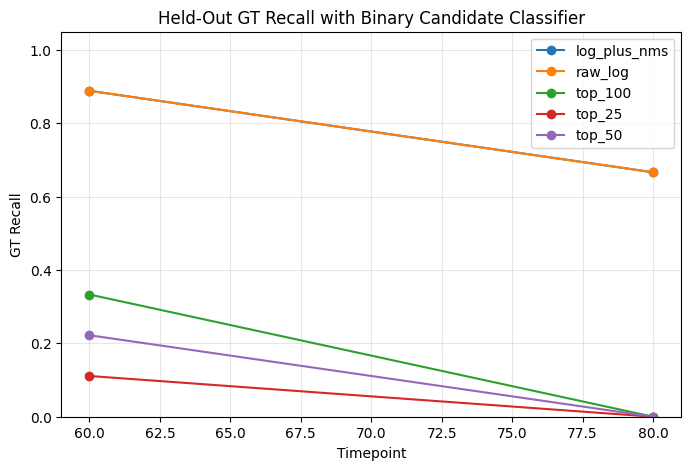

In [19]:
plt.figure(figsize=(8, 5))

for detector_name, group in heldout_results_df.groupby("detector"):
    plt.plot(group["t"], group["gt_recall"], marker="o", label=detector_name)

plt.title("Held-Out GT Recall with Binary Candidate Classifier")
plt.xlabel("Timepoint")
plt.ylabel("GT Recall")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

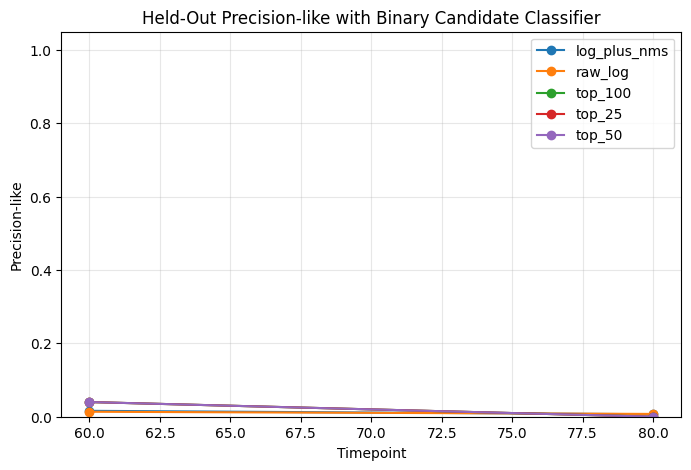

In [20]:
plt.figure(figsize=(8, 5))

for detector_name, group in heldout_results_df.groupby("detector"):
    plt.plot(group["t"], group["pred_precision_like"], marker="o", label=detector_name)

plt.title("Held-Out Precision-like with Binary Candidate Classifier")
plt.xlabel("Timepoint")
plt.ylabel("Precision-like")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Step 9 — Inspect Ranked Candidates on a Held-Out Frame

I will inspect the held-out timepoint `t = 60` and check where oracle-good candidates appear under the classifier ranking.

In [21]:
t_inspect = 60

ranked_t = heldout_ranked[t_inspect]
ranked_t[
    ["rank_position", "z", "y", "x", "nearest_gt_dist", "oracle_good", "pred_prob_good"]
].head(30)

,rank_position,z,y,x,nearest_gt_dist,oracle_good,pred_prob_good
0,1,15,229,12,34.899857,False,0.485190
1,2,19,17,198,36.262929,False,0.479637
2,3,34,14,70,85.854528,False,0.457184
3,4,10,196,111,26.702060,False,0.455830
4,5,18,187,69,12.649111,False,0.439300
5,6,43,77,178,22.561028,False,0.420633
6,7,31,162,233,94.387499,False,0.420468
7,8,43,61,32,104.067286,False,0.413986
8,9,36,148,120,22.338308,False,0.410824
9,10,6,206,10,49.678969,False,0.408169


In [22]:
good_ranked_t = ranked_t[ranked_t["oracle_good"]].copy()

good_ranked_t[
    ["rank_position", "z", "y", "x", "nearest_gt_dist", "pred_prob_good"]
].sort_values("rank_position")

,rank_position,z,y,x,nearest_gt_dist,pred_prob_good
12,13,25,215,110,4.242641,0.398903
38,39,16,195,63,4.898979,0.341268
57,58,27,219,112,2.449490,0.307296
84,85,24,204,71,5.099020,0.279876
151,152,39,158,62,5.916080,0.219500
303,304,33,145,145,5.656854,0.125671
324,325,34,47,222,5.830952,0.112224
404,405,43,163,70,5.099020,0.079357
642,643,25,210,78,4.242641,0.019591
675,676,41,156,64,4.358899,0.012123


In [23]:
bad_top_t = ranked_t[~ranked_t["oracle_good"]].head(20)

bad_top_t[
    ["rank_position", "z", "y", "x", "nearest_gt_dist", "pred_prob_good"]
]

,rank_position,z,y,x,nearest_gt_dist,pred_prob_good
0,1,15,229,12,34.899857,0.485190
1,2,19,17,198,36.262929,0.479637
2,3,34,14,70,85.854528,0.457184
3,4,10,196,111,26.702060,0.455830
4,5,18,187,69,12.649111,0.439300
5,6,43,77,178,22.561028,0.420633
6,7,31,162,233,94.387499,0.420468
7,8,43,61,32,104.067286,0.413986
8,9,36,148,120,22.338308,0.410824
9,10,6,206,10,49.678969,0.408169


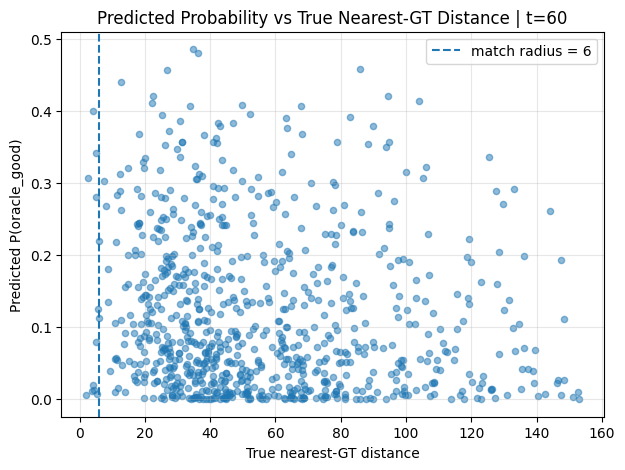

In [24]:
plt.figure(figsize=(7, 5))

plt.scatter(
    ranked_t["nearest_gt_dist"],
    ranked_t["pred_prob_good"],
    alpha=0.5,
    s=20
)

plt.axvline(match_radius, linestyle="--", label=f"match radius = {match_radius}")

plt.title(f"Predicted Probability vs True Nearest-GT Distance | t={t_inspect}")
plt.xlabel("True nearest-GT distance")
plt.ylabel("Predicted P(oracle_good)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

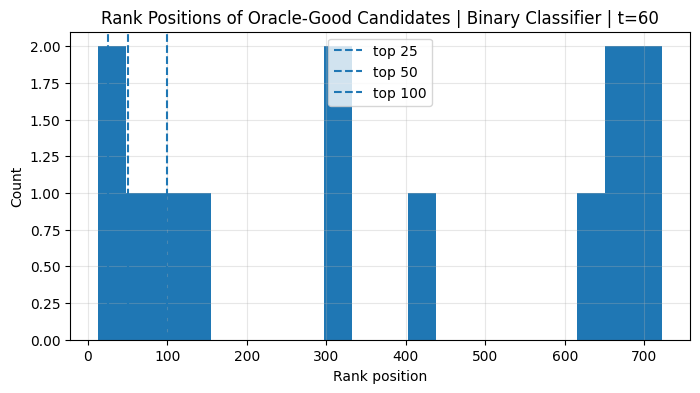

In [25]:
plt.figure(figsize=(8, 4))

plt.hist(good_ranked_t["rank_position"], bins=20)

plt.axvline(25, linestyle="--", label="top 25")
plt.axvline(50, linestyle="--", label="top 50")
plt.axvline(100, linestyle="--", label="top 100")

plt.title(f"Rank Positions of Oracle-Good Candidates | Binary Classifier | t={t_inspect}")
plt.xlabel("Rank position")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [26]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
7,patch_com_offset,0.129894
12,z_support_min,0.092357
4,patch_std,0.091113
3,patch_max,0.090570
11,z_support_std,0.086449
2,patch_mean,0.086425
13,z_support_max,0.082255
5,local_contrast,0.079001
10,z_support_mean,0.078175
1,center_intensity,0.073060


# Step 10 — Interpretation Guide

This chapter answers one question:

> Does a binary classifier rank GT-near candidates better than distance regression?

## If top-k recall improves
Then classification is a better ranking target than distance regression.

## If oracle-good candidates move closer to the top
Then the classifier is learning a more useful signal.

## If top-k still fails
Then the limitation is probably not the regression target itself, but the feature set or model family.